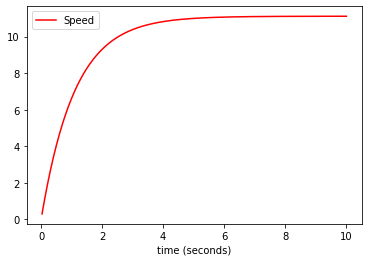

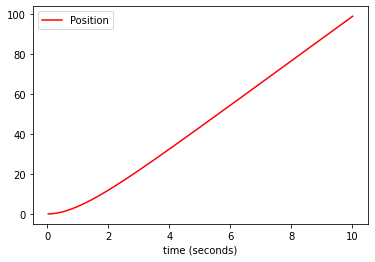

In [1]:
#
# to be tested with godot/cart-1d-no-physics
#

#
# CART 1D WITH CONSTANT INPUT
#

import sys
import time
sys.path.append("../../")

from lib.data.dataplot import *
from lib.utils.time import *
from lib.system.cart import *
from lib.dds.dds import *

spd = DataPlotter()
spd.set_x("time (seconds)")
spd.add_y("speed", "Speed")

pos = DataPlotter()
pos.set_x("time (seconds)")
pos.add_y("pos", "Position")

cart = Cart(1.0, 0.9)

force = 10

dds = DDS()
dds.start()

dds.subscribe(['tick'])

t = Time()
t.start()
while t.get() < 10:

    dds.wait('tick')
    delta_t = t.elapsed()
    
    (p, v) = cart.evaluate(delta_t, force)
    
    dds.publish('position', p, DDS.DDS_TYPE_FLOAT)
    
    spd.append_x(t.get())
    spd.append_y("speed", v)
    
    pos.append_x(t.get())
    pos.append_y("pos", p)

dds.stop()

spd.plot()
pos.plot()
